<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Intrinsic Validation 6 - RuntimeContext
---
This notebook collects dtype and device comparisons for the Standard Model, NSI and $3+1$ sterile-neutrino extension.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Standard-Model) | **Standard Model** |
| [4](#4.-NSI) | **NSI** |
| [5](#5.-31-Sterile-Neutrino) | **$3+1$ Sterile Neutrino** |
| [6](#6.-Summary) | **Summary** |


## 0. Theoretical Framework
---
`RuntimeContext` controls the Torch device and real dtype used to construct oscillation parameters, profiles, grids and state tensors. A valid comparison must rebuild every model-dependent tensor on the tested context rather than moving only the final input array. `float64` numerical propagation is the precision reference; numerical CUDA is the device reference. All probabilities include the full flavour dimension of the selected model.

**References**

No external references are cited in this notebook.


## 1. Libraries

This stage evaluates libraries under the physical hypotheses and numerical controls defined above, retaining explicit dimensional, normalization, and convergence diagnostics.


In [1]:
from __future__ import annotations
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import ABSOLUTE_THRESHOLD, save_and_show, to_numpy, validation_metrics, validation_summary_plot
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.util.context import RuntimeContext


## 2. Paths and Configuration

This stage evaluates paths and configuration under the physical hypotheses and numerical controls defined above, retaining explicit dimensional, normalization, and convergence diagnostics.


### 2.1 Paths

`load_notebook_config()` resolves the package directory and the common Torch, NumPy and plotting configuration. Generated figures are written under `validation/intrinsic/`.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('validation', 'intrinsic')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\validation\intrinsic
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

The three model sections use identical Earth, energy, angular, depth, precision and error-threshold settings. Only the oscillation/BSM model is changed.


In [3]:
SM_PRESET = '_SM_NUFIT52_NO'
NSI_PRESET = 'nsi_globalfit_esteban2018'
STERILE_PRESET = 'sterile_3p1_bestfit_giunti2017'
MODEL_LABELS = {'sm': 'Standard Model', 'nsi': 'NSI', 'sterile': '3+1 sterile'}
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
LEGACY_PRECISION = False
ABSOLUTE_THRESHOLD = 1e-3
earth = EarthProfile(params=EarthParameters(density_provider='prem', profile_perturbative_name='even_power', profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=context)
def model_oscillation(model, runtime_context=context):
    if model == 'sm':
        return PropagationConfig.oscillation_parameters_from_preset(SM_PRESET, context=runtime_context, antinu=False)
    if model == 'nsi':
        return PropagationConfig.oscillation_parameters_from_preset(SM_PRESET, context=runtime_context, antinu=False, NSI_extension=NSI_PRESET)
    if model == 'sterile':
        return PropagationConfig.oscillation_parameters_from_preset(STERILE_PRESET, context=runtime_context, antinu=False)
    raise ValueError(f'Unknown model: {model!r}')
def select_model(model):
    global oscillation, N_FLAVOURS, CDTYPE, BASIS, FLAVOUR_LABELS, FLAVOUR_COLOURS
    oscillation = model_oscillation(model)
    N_FLAVOURS = int(oscillation.pmns.n_flavours)
    CDTYPE = torch.complex128 if context.dtype == torch.float64 else torch.complex64
    BASIS = torch.eye(N_FLAVOURS, device=context.device, dtype=CDTYPE)
    FLAVOUR_LABELS = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$'] + ([r'$\nu_s$'] if N_FLAVOURS == 4 else [])
    FLAVOUR_COLOURS = tuple(f'C{i}' for i in range(N_FLAVOURS))
    print(f'{MODEL_LABELS[model]}: {N_FLAVOURS} flavours, preset={oscillation.preset_name}')


### 2.3 Local Helpers

The helpers below centralize the repeated scans and plotting logic while each model section explicitly selects its own oscillation parameters and flavour dimension.


In [4]:
RUNTIME_SUMMARIES = []
E_STUDY_CPU = torch.logspace(np.log10(100.0),np.log10(2e4),60,dtype=torch.float64)
ETA_STUDY_CPU = torch.linspace(0.05,1.50,60,dtype=torch.float64)
def runtime_two_scans(model, method, dtype, device):
    runtime_context=RuntimeContext.resolve(device,dtype); runtime_oscillation=model_oscillation(model,runtime_context)
    runtime_earth=EarthProfile(params=EarthParameters(density_provider='prem',profile_perturbative_name='even_power',profile_perturbative_kwargs={'density_file':str(config.earth_density_file),'tabulated_density':False}),context=runtime_context)
    n_flavours=int(runtime_oscillation.pmns.n_flavours); cdtype=torch.complex128 if dtype==torch.float64 else torch.complex64
    state=torch.zeros(n_flavours,device=runtime_context.device,dtype=cdtype); state[0]=1
    energy=E_STUDY_CPU.to(device=runtime_context.device,dtype=dtype); angles=ETA_STUDY_CPU.to(device=runtime_context.device,dtype=dtype)
    fixed_eta=torch.tensor(0.60,device=runtime_context.device,dtype=dtype); fixed_energy=torch.tensor(5000.0,device=runtime_context.device,dtype=dtype)
    energy_scan=earth_probability_state(state,runtime_earth,runtime_oscillation,energy[:,None],fixed_eta,DEPTH_M,method=method,massbasis=False,nsteps=N_EARTH_STEPS,context=runtime_context,reunitarize=False,legacy_precision=LEGACY_PRECISION).reshape(energy.numel(),n_flavours)
    angle_scan=torch.stack([earth_probability_state(state,runtime_earth,runtime_oscillation,fixed_energy,eta,DEPTH_M,method=method,massbasis=False,nsteps=N_EARTH_STEPS,context=runtime_context,reunitarize=False,legacy_precision=LEGACY_PRECISION) for eta in angles])
    return energy_scan.cpu().to(torch.float64),angle_scan.cpu().to(torch.float64)
def runtime_plot(model, reference, cases, prefix, reference_label):
    rows=[]
    for label,tested in cases.items():
        row,_,_=validation_metrics(label,torch.cat(reference),torch.cat(tested),reference_label=reference_label,tested_label=label,absolute_threshold=ABSOLUTE_THRESHOLD); row['case']=f'{MODEL_LABELS[model]}: {label} vs {reference_label}'; rows.append(row); RUNTIME_SUMMARIES.append(row)
    display(pd.DataFrame(rows).set_index('case').style.format('{:.3e}'))
    fig,axes=plt.subplots(3,2,figsize=(14,11),sharex='col')
    for column,(x,index,xlabel) in enumerate([(E_STUDY_CPU,0,'E [MeV]'),(ETA_STUDY_CPU,1,'eta [rad]')]):
        ref=reference[index]; axes[0,column].plot(to_numpy(x),to_numpy(ref[:,0]),color='black',lw=2,label=reference_label)
        for case_index,(label,tested) in enumerate(cases.items()):
            scan=tested[index]; colour=f'C{case_index+1}'; axes[0,column].plot(to_numpy(x),to_numpy(scan[:,0]),label=label,color=colour)
            _,absolute,relative=validation_metrics(label,ref,scan,absolute_threshold=ABSOLUTE_THRESHOLD); axes[1,column].plot(to_numpy(x),to_numpy(absolute.amax(dim=-1)),label=label,color=colour); axes[2,column].plot(to_numpy(x),to_numpy(relative.amax(dim=-1)),label=label,color=colour)
        axes[0,column].legend(fontsize=7); axes[1,column].set_yscale('log'); axes[2,column].set_yscale('log'); axes[2,column].set_xlabel(xlabel)
    for ax,label in zip(axes[:,0],[r'$P_{ee}$','Maximum absolute error','Maximum relative error']): ax.set_ylabel(label)
    for ax in axes.flat: ax.grid(alpha=.25)
    fig.suptitle(f'{MODEL_LABELS[model]}: {reference_label} reference'); fig.tight_layout(); save_and_show(prefix,fig,output_dir=OUTPUT_DIR,show_plots=config.show_plots)
def precision_study(model,prefix):
    reference=runtime_two_scans(model,'numerical',torch.float64,context.device)
    cases={'perturbative float64':runtime_two_scans(model,'analytical',torch.float64,context.device),'numerical float32':runtime_two_scans(model,'numerical',torch.float32,context.device),'perturbative float32':runtime_two_scans(model,'analytical',torch.float32,context.device)}
    runtime_plot(model,reference,cases,f'{prefix}_precision.png','numerical float64')
def device_study(model,prefix):
    if not torch.cuda.is_available(): raise RuntimeError('CUDA comparison requires an available CUDA device.')
    reference=runtime_two_scans(model,'numerical',torch.float64,'cuda')
    cases={'perturbative CUDA':runtime_two_scans(model,'analytical',torch.float64,'cuda'),'numerical CPU':runtime_two_scans(model,'numerical',torch.float64,'cpu'),'perturbative CPU':runtime_two_scans(model,'analytical',torch.float64,'cpu')}
    runtime_plot(model,reference,cases,f'{prefix}_device.png','numerical CUDA')


## 3. Standard Model

The physical scenario is coherent pure-$\nu_e$ propagation through Earth with the Standard Model Hamiltonian.

**Expected results:**<br>
- The standard model observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 3.1 Float32/Float64 Precision

Numerical `float64` is the reference. Perturbative `float64`, numerical `float32` and perturbative `float32` are tested against it.

**Expected results:**<br>
- The float32/float64 precision observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 3.2 CPU/CUDA Device

Numerical CUDA with `float64` is the reference. Numerical CPU and both perturbative devices are compared using freshly constructed contexts.

**Expected results:**<br>
- The cpu/cuda device observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical float64,normalization_perturbative float64,relative_points,absolute_threshold,normalization_numerical float32,normalization_perturbative float32
case,,,,,,,,,,
Standard Model: perturbative float64 vs numerical float64,1.600e-02,1.376e-03,1.558e-01,7.666e-03,8.571e-14,1.556e-02,3.540e+02,1.000e-03,nan,nan
Standard Model: numerical float32 vs numerical float64,1.036e-04,1.115e-05,1.747e-04,3.350e-05,8.571e-14,nan,3.540e+02,1.000e-03,1.089e-04,nan
Standard Model: perturbative float32 vs numerical float64,1.602e-02,1.377e-03,1.564e-01,7.669e-03,8.571e-14,nan,3.540e+02,1.000e-03,nan,1.557e-02


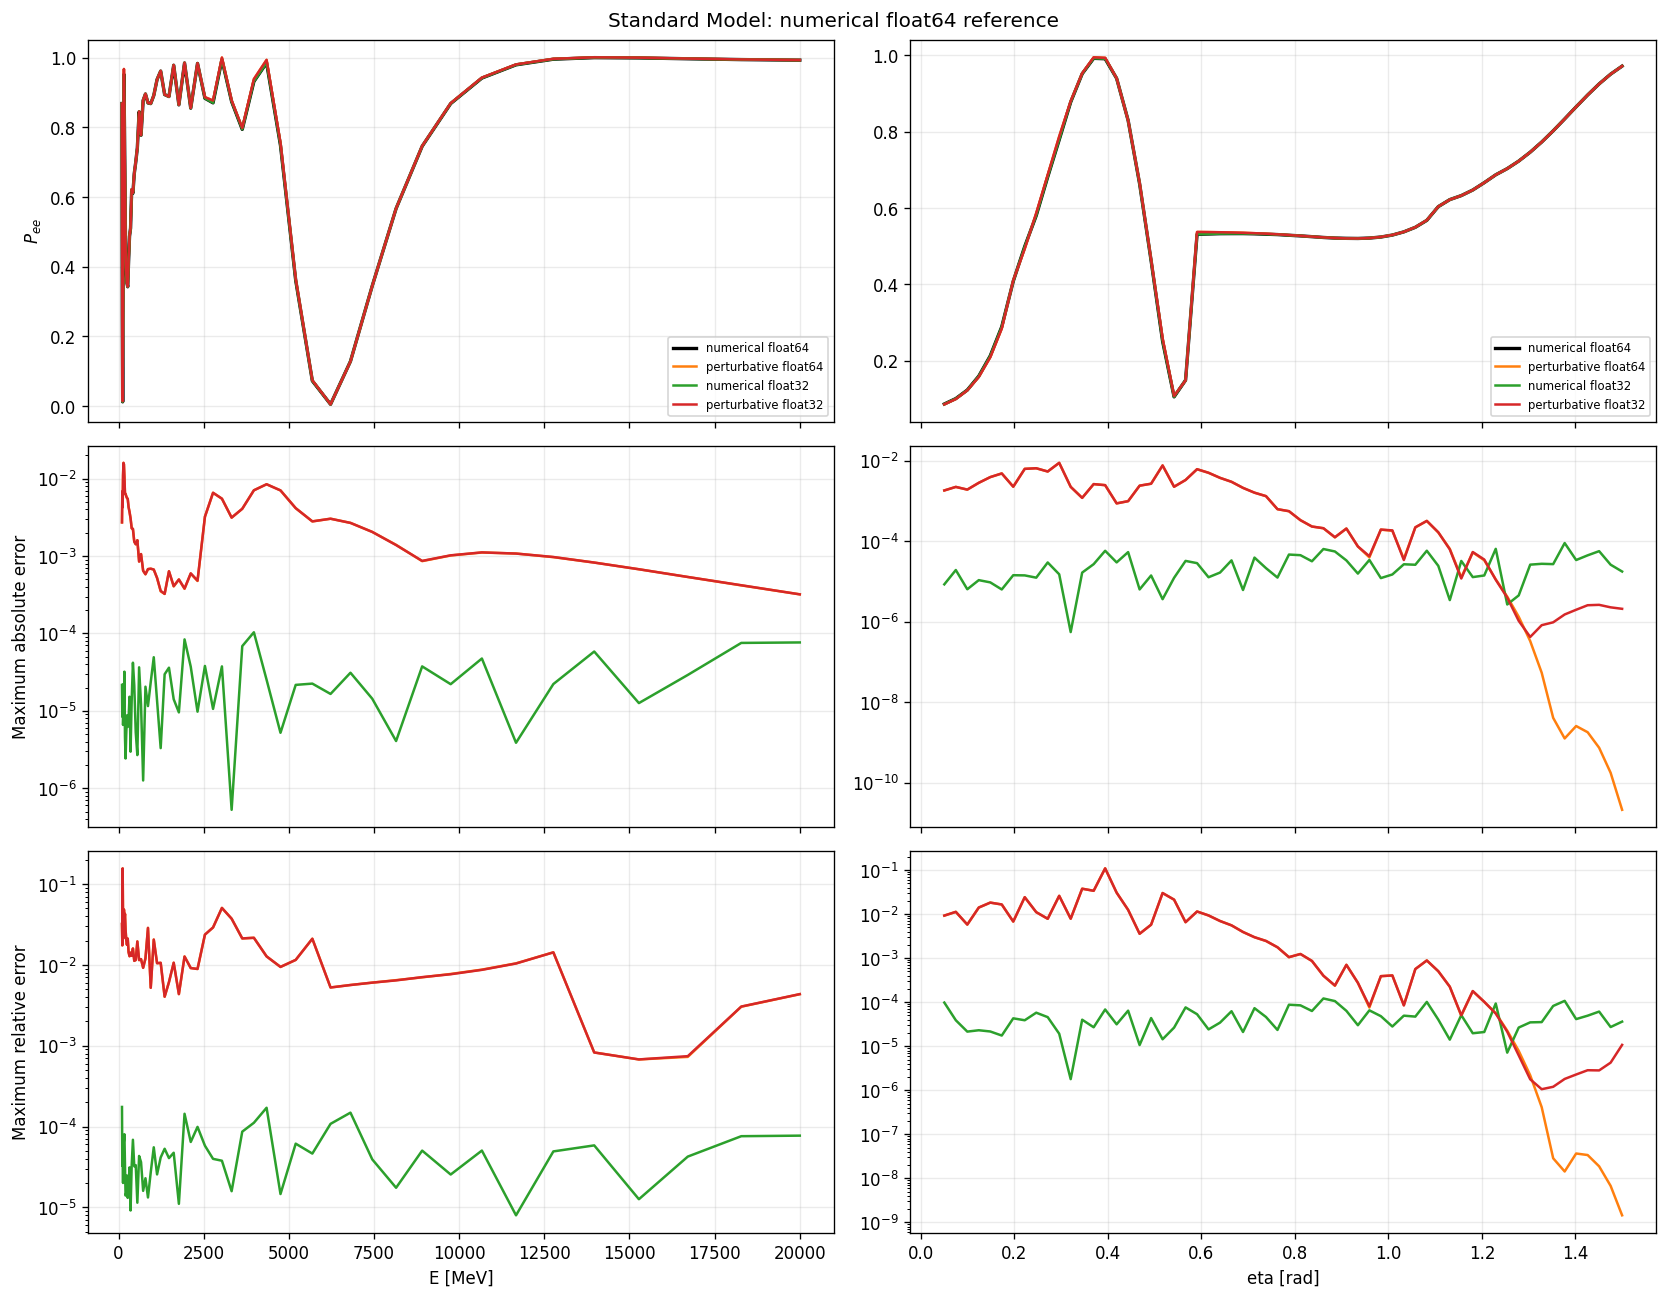

v:\output\validation\intrinsic\intrinsic6_sm_fig31_precision.png


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical CUDA,normalization_perturbative CUDA,relative_points,absolute_threshold,normalization_numerical CPU,normalization_perturbative CPU
case,,,,,,,,,,
Standard Model: perturbative CUDA vs numerical CUDA,1.600e-02,1.376e-03,1.558e-01,7.666e-03,8.571e-14,1.556e-02,3.540e+02,1.000e-03,nan,nan
Standard Model: numerical CPU vs numerical CUDA,4.918e-14,2.381e-15,3.059e-13,1.020e-14,8.571e-14,nan,3.540e+02,1.000e-03,8.482e-14,nan
Standard Model: perturbative CPU vs numerical CUDA,1.600e-02,1.376e-03,1.558e-01,7.666e-03,8.571e-14,nan,3.540e+02,1.000e-03,nan,1.556e-02


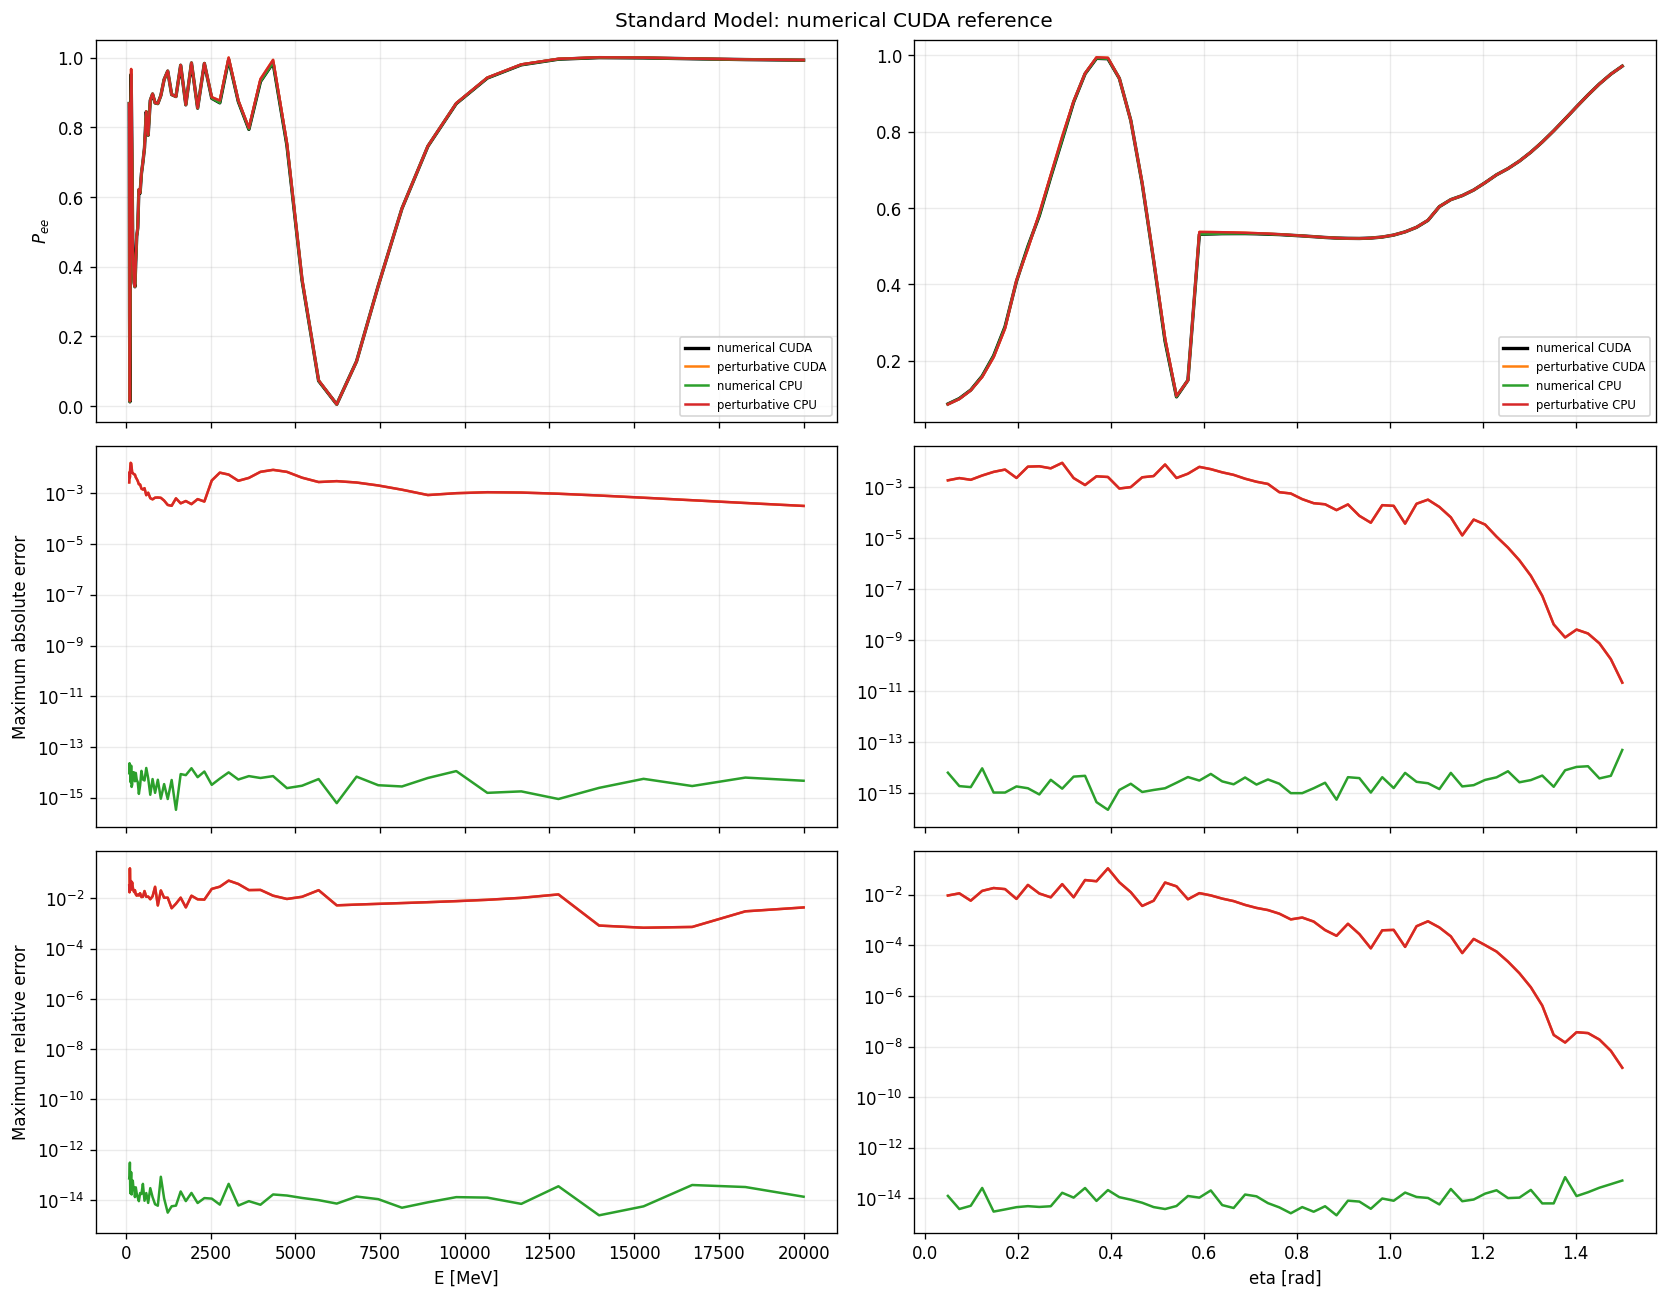

v:\output\validation\intrinsic\intrinsic6_sm_fig32_device.png


In [5]:
precision_study('sm','intrinsic6_sm_fig31')
device_study('sm','intrinsic6_sm_fig32')


## 4. NSI

The physical scenario is coherent pure-$\nu_e$ propagation through Earth with the NSI Hamiltonian.

**Expected results:**<br>
- The nsi observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 4.1 Float32/Float64 Precision

Numerical `float64` is the reference. Perturbative `float64`, numerical `float32` and perturbative `float32` are tested against it.

**Expected results:**<br>
- The float32/float64 precision observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 4.2 CPU/CUDA Device

Numerical CUDA with `float64` is the reference. Numerical CPU and both perturbative devices are compared using freshly constructed contexts.

**Expected results:**<br>
- The cpu/cuda device observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical float64,normalization_perturbative float64,relative_points,absolute_threshold,normalization_numerical float32,normalization_perturbative float32
case,,,,,,,,,,
NSI: perturbative float64 vs numerical float64,2.624e-02,1.538e-03,1.910e-01,1.242e-02,7.105e-14,2.365e-02,3.570e+02,1.000e-03,nan,nan
NSI: numerical float32 vs numerical float64,8.550e-05,1.070e-05,2.304e-04,3.364e-05,7.105e-14,nan,3.570e+02,1.000e-03,1.113e-04,nan
NSI: perturbative float32 vs numerical float64,2.624e-02,1.539e-03,1.903e-01,1.242e-02,7.105e-14,nan,3.570e+02,1.000e-03,nan,2.367e-02


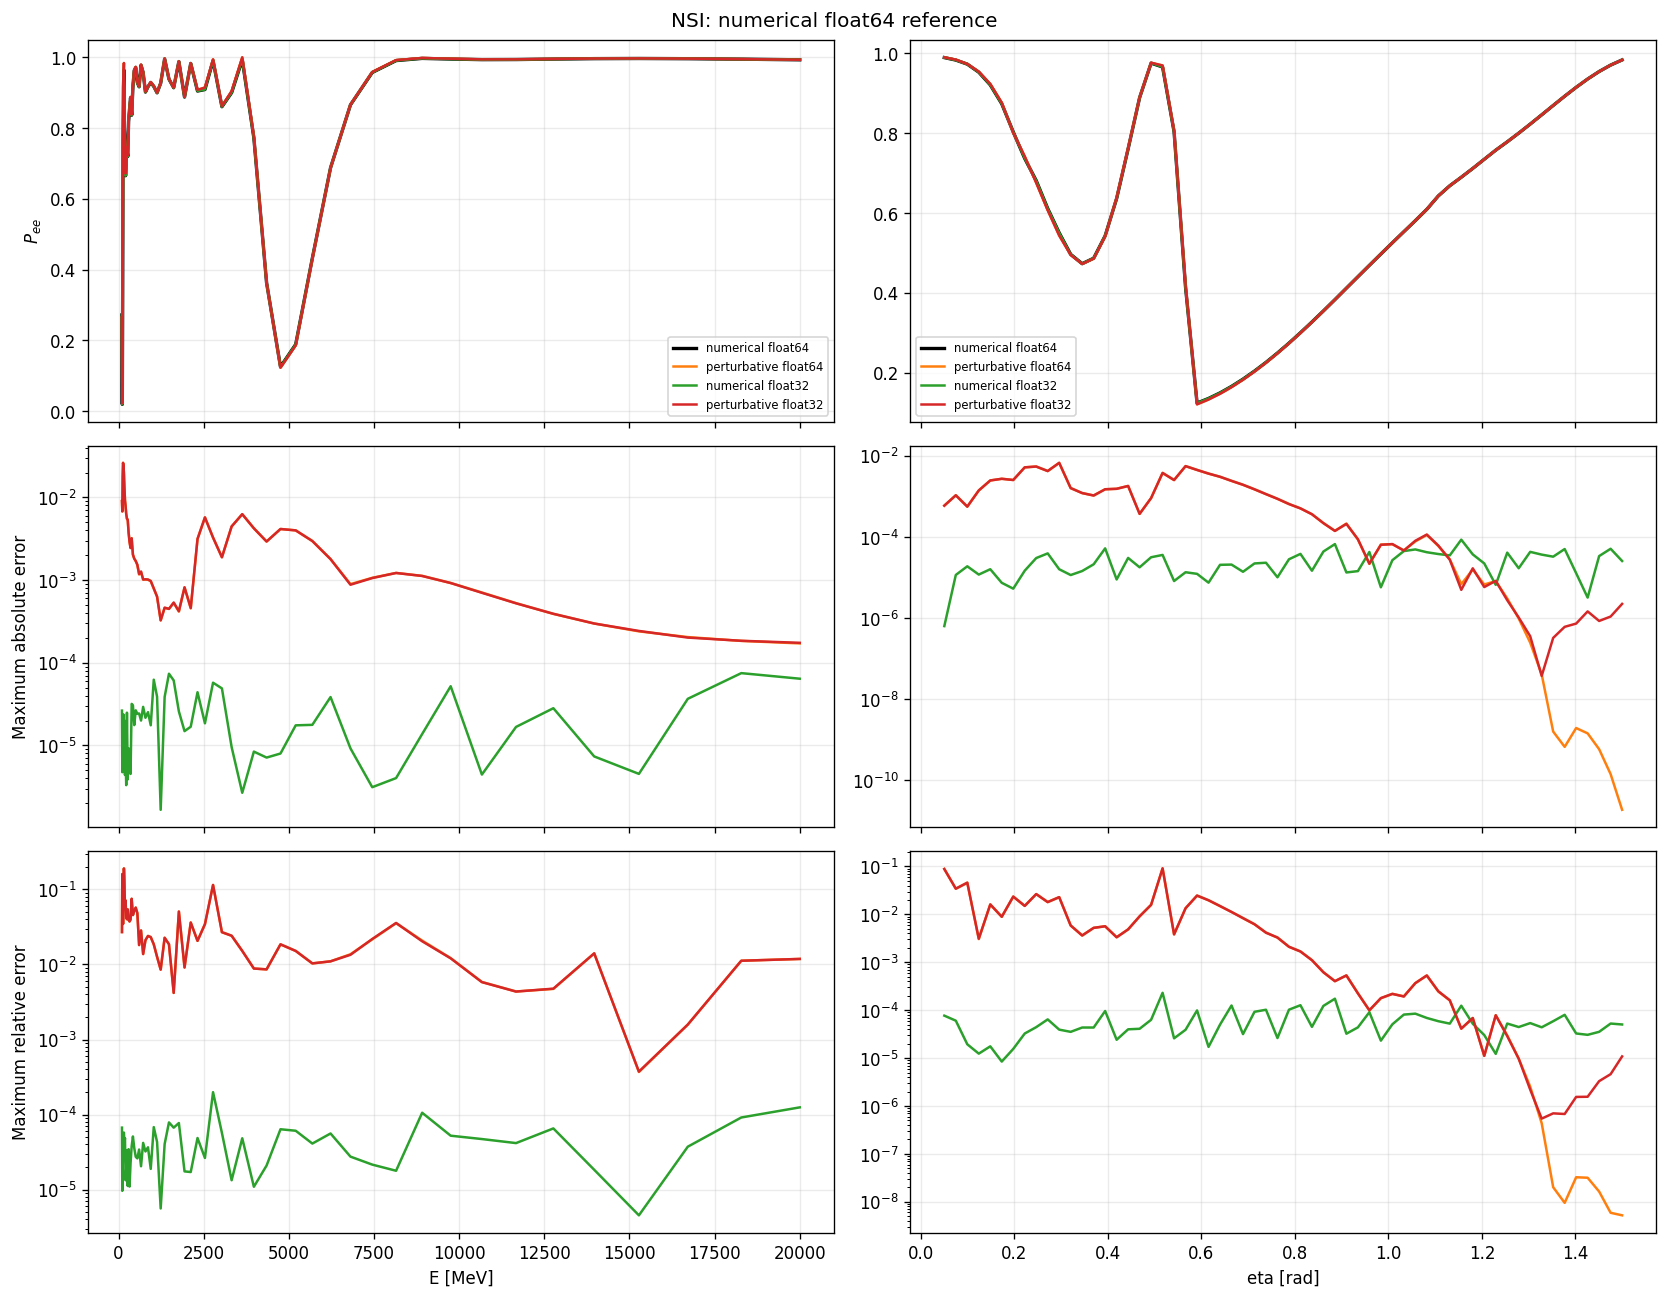

v:\output\validation\intrinsic\intrinsic6_nsi_fig41_precision.png


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical CUDA,normalization_perturbative CUDA,relative_points,absolute_threshold,normalization_numerical CPU,normalization_perturbative CPU
case,,,,,,,,,,
NSI: perturbative CUDA vs numerical CUDA,2.624e-02,1.538e-03,1.910e-01,1.242e-02,7.105e-14,2.365e-02,3.570e+02,1.000e-03,nan,nan
NSI: numerical CPU vs numerical CUDA,2.992e-14,2.125e-15,9.828e-14,8.912e-15,7.105e-14,nan,3.570e+02,1.000e-03,6.883e-14,nan
NSI: perturbative CPU vs numerical CUDA,2.624e-02,1.538e-03,1.910e-01,1.242e-02,7.105e-14,nan,3.570e+02,1.000e-03,nan,2.365e-02


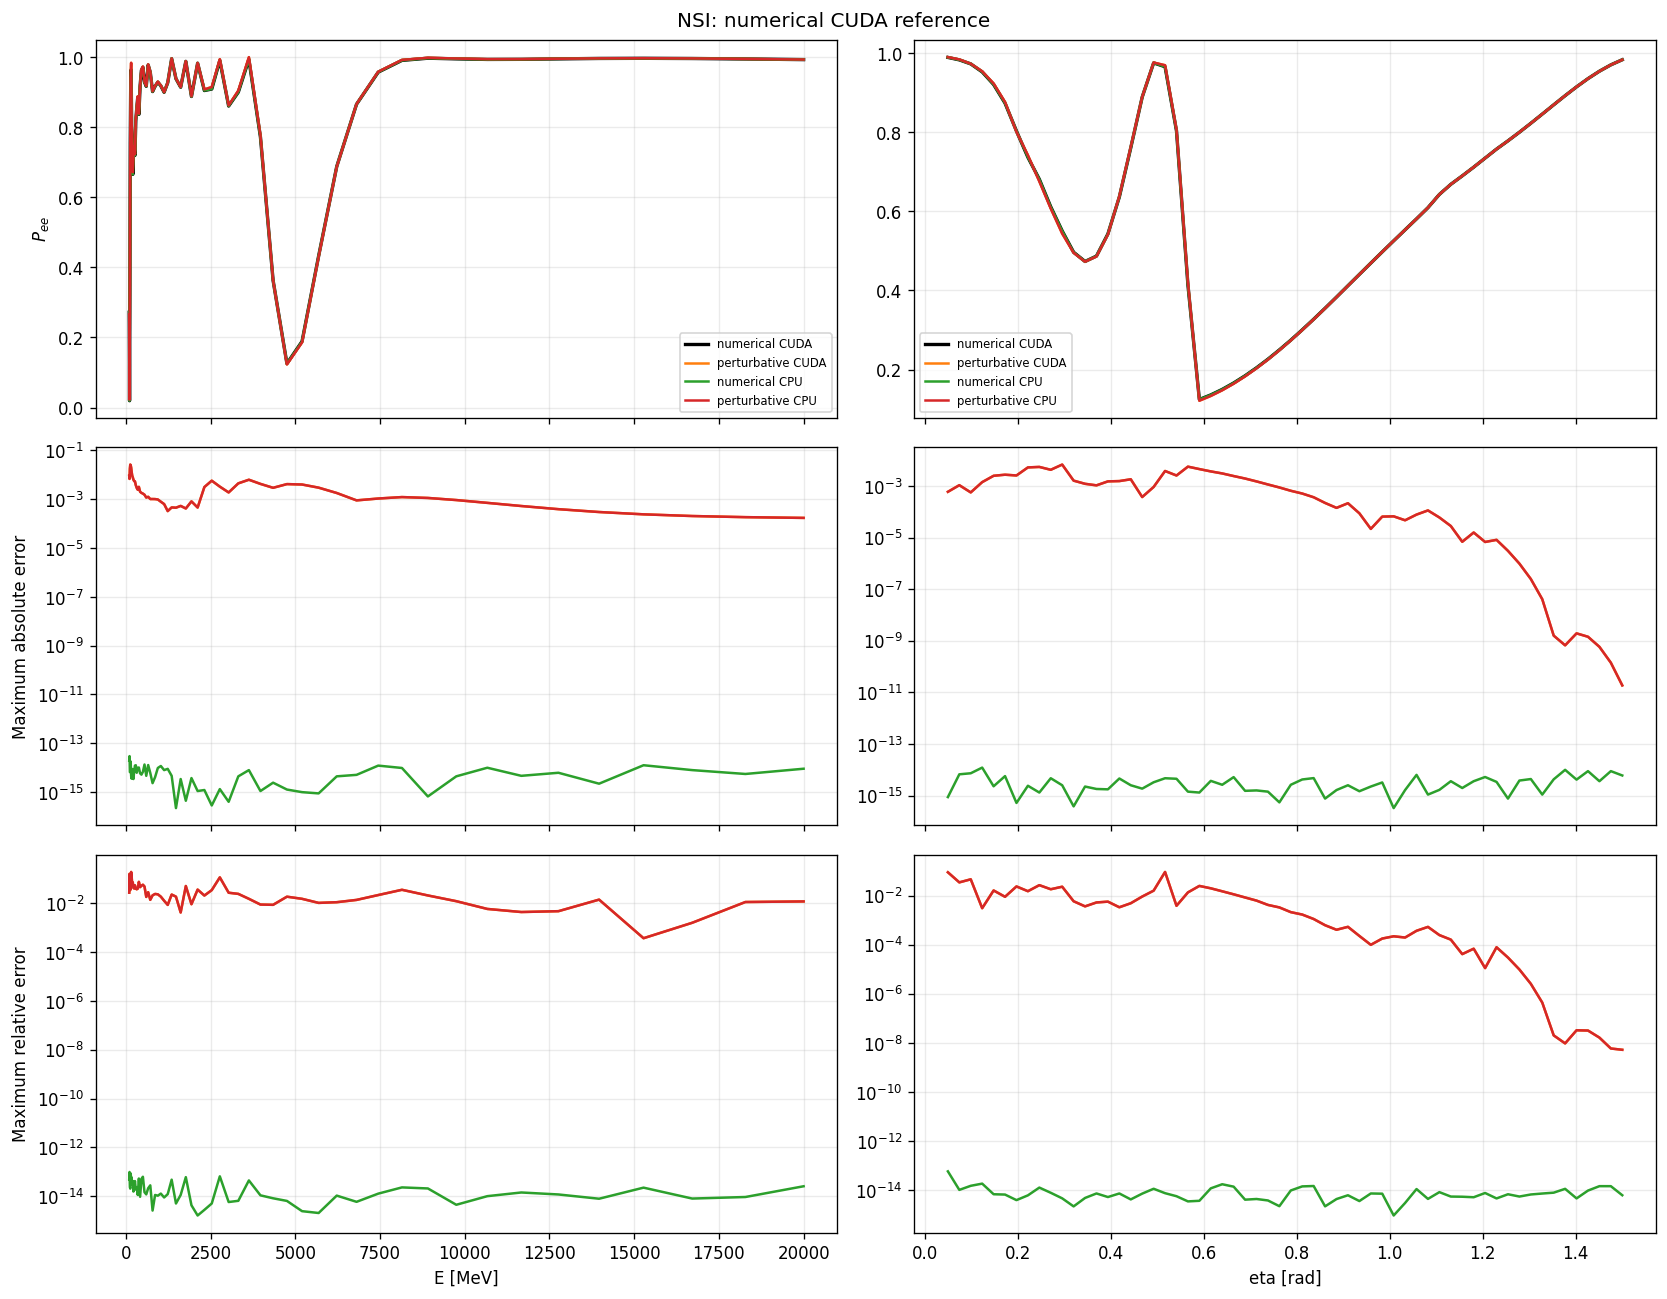

v:\output\validation\intrinsic\intrinsic6_nsi_fig42_device.png


In [6]:
precision_study('nsi','intrinsic6_nsi_fig41')
device_study('nsi','intrinsic6_nsi_fig42')


## 5. $3+1$ Sterile Neutrino

The physical scenario is coherent pure-$\nu_e$ propagation through Earth with the $3+1$ Sterile Neutrino Hamiltonian.

**Expected results:**<br>
- The $3+1$ sterile neutrino observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 5.1 Float32/Float64 Precision

Numerical `float64` is the reference. Perturbative `float64`, numerical `float32` and perturbative `float32` are tested against it.

**Expected results:**<br>
- The float32/float64 precision observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


### 5.2 CPU/CUDA Device

Numerical CUDA with `float64` is the reference. Numerical CPU and both perturbative devices are compared using freshly constructed contexts.

**Expected results:**<br>
- The cpu/cuda device observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\medium\earth\probability.py:539: RuntimeWarning: earth_probability_state_numerical: the 3+1 sterile extension is active but no neutron-density data is available for this profile/model, so the neutral-current matter term cannot be included. Falling back to the CC-only sterile Hamiltonian (include_matter_nc=False) -- pass include_matter_nc=False explicitly to silence this warning, or build the profile with neutron-density support to get the physically complete 3+1 Hamiltonian.
  return earth_probability_state_numerical(
G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\medium\earth\probability.py:193: RuntimeWarning: earth_evolutor: the 3+1 sterile extension is active but no neutron-density data is available for this profile/model, so the neutral-current matter term cannot be included. Falling back to the CC-only sterile Hamiltonian (include_matter_nc=False) -- pass include_matter_nc=False explicitly to silence this warning, or build the profile with n

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical float64,normalization_perturbative float64,relative_points,absolute_threshold,normalization_numerical float32,normalization_perturbative float32
case,,,,,,,,,,
3+1 sterile: perturbative float64 vs numerical float64,1.481e-02,9.974e-04,1.729e-01,6.723e-03,5.653e-11,1.491e-02,4.670e+02,1.000e-03,nan,nan
3+1 sterile: numerical float32 vs numerical float64,3.604e-02,8.081e-04,2.673e-01,4.789e-03,5.653e-11,nan,4.670e+02,1.000e-03,4.792e-02,nan
3+1 sterile: perturbative float32 vs numerical float64,1.391e+00,2.737e-02,7.504e+00,1.341e-01,5.653e-11,nan,4.670e+02,1.000e-03,nan,1.444e+00


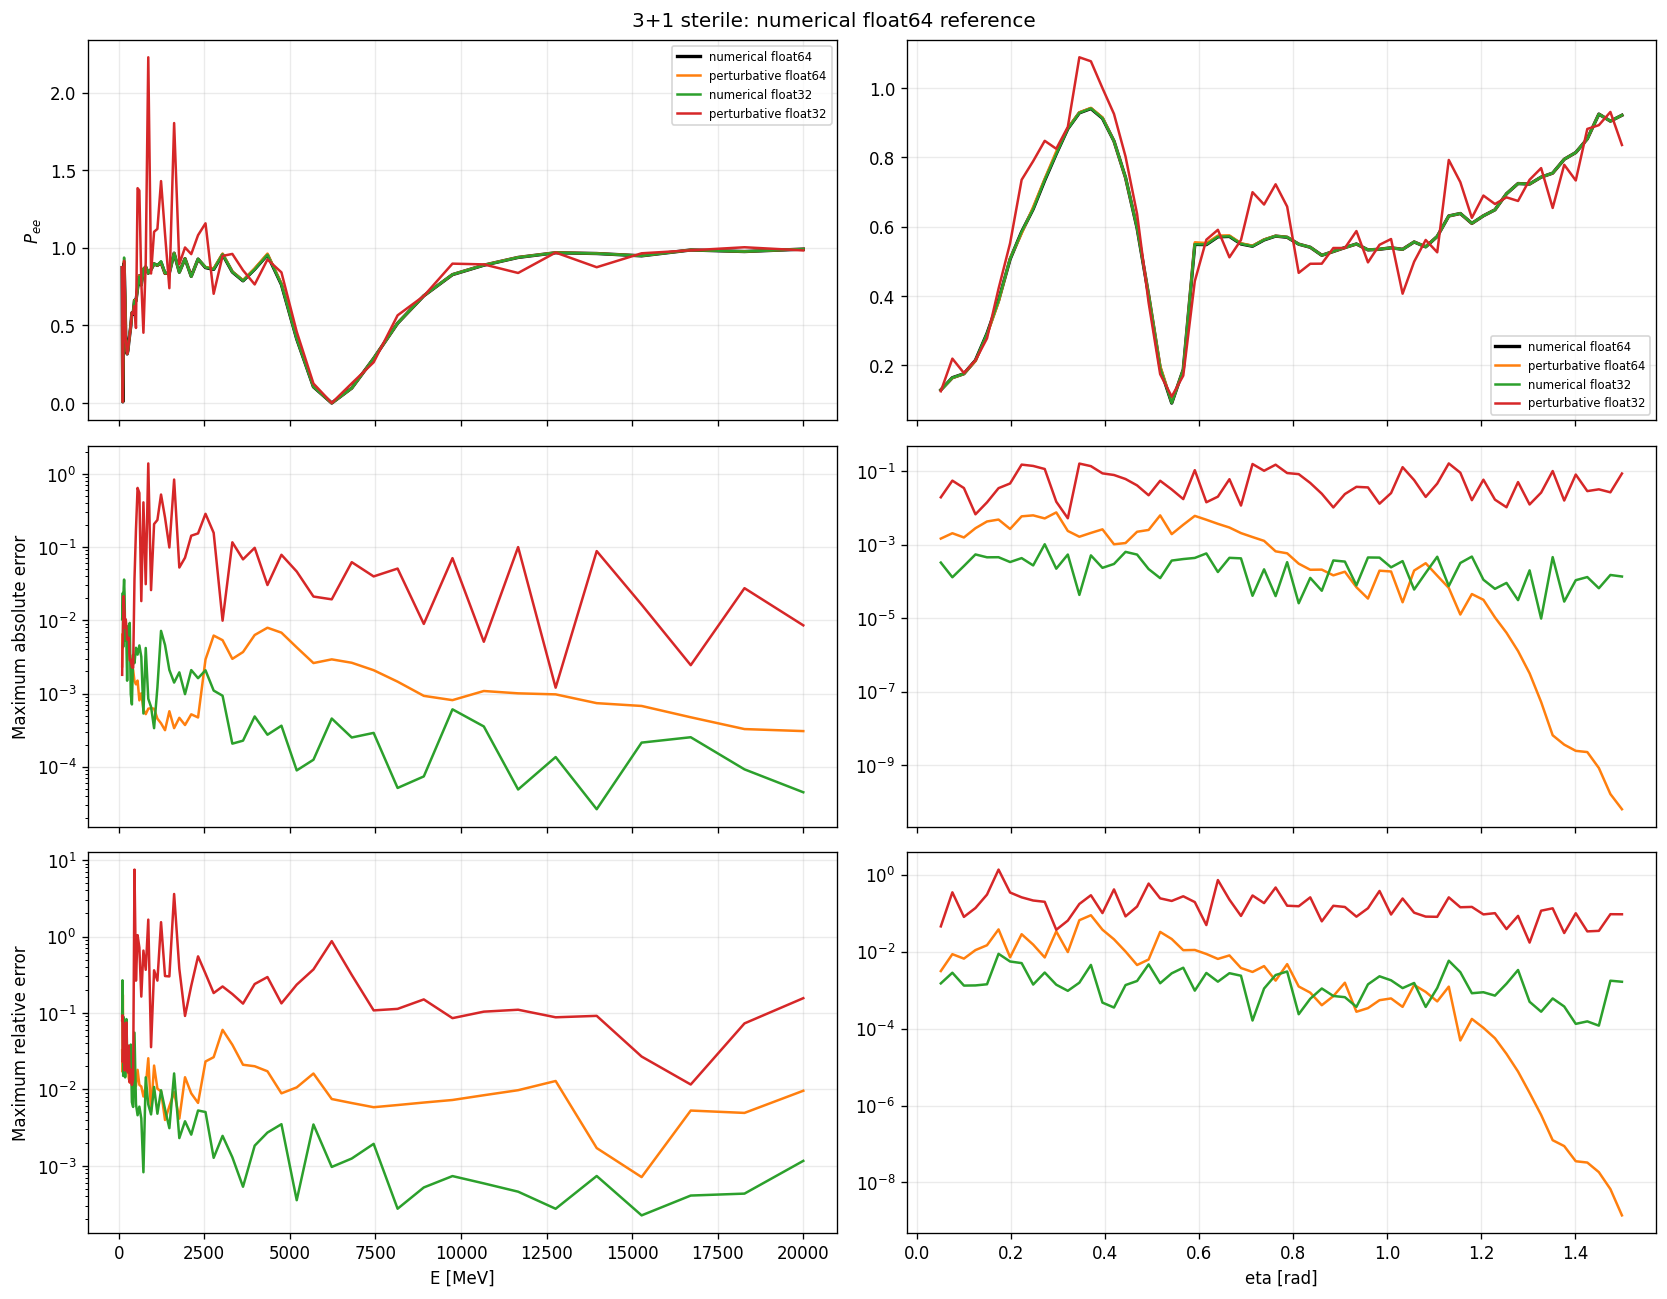

v:\output\validation\intrinsic\intrinsic6_sterile_fig51_precision.png


G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\medium\earth\probability.py:539: RuntimeWarning: earth_probability_state_numerical: the 3+1 sterile extension is active but no neutron-density data is available for this profile/model, so the neutral-current matter term cannot be included. Falling back to the CC-only sterile Hamiltonian (include_matter_nc=False) -- pass include_matter_nc=False explicitly to silence this warning, or build the profile with neutron-density support to get the physically complete 3+1 Hamiltonian.
  return earth_probability_state_numerical(
G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\medium\earth\probability.py:193: RuntimeWarning: earth_evolutor: the 3+1 sterile extension is active but no neutron-density data is available for this profile/model, so the neutral-current matter term cannot be included. Falling back to the CC-only sterile Hamiltonian (include_matter_nc=False) -- pass include_matter_nc=False explicitly to silence this warning, or build the profile with n

,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical CUDA,normalization_perturbative CUDA,relative_points,absolute_threshold,normalization_numerical CPU,normalization_perturbative CPU
case,,,,,,,,,,
3+1 sterile: perturbative CUDA vs numerical CUDA,1.481e-02,9.974e-04,1.729e-01,6.723e-03,5.653e-11,1.491e-02,4.670e+02,1.000e-03,nan,nan
3+1 sterile: numerical CPU vs numerical CUDA,2.313e-11,4.057e-13,2.263e-10,3.481e-12,5.653e-11,nan,4.670e+02,1.000e-03,6.399e-11,nan
3+1 sterile: perturbative CPU vs numerical CUDA,1.481e-02,9.974e-04,1.729e-01,6.723e-03,5.653e-11,nan,4.670e+02,1.000e-03,nan,1.491e-02


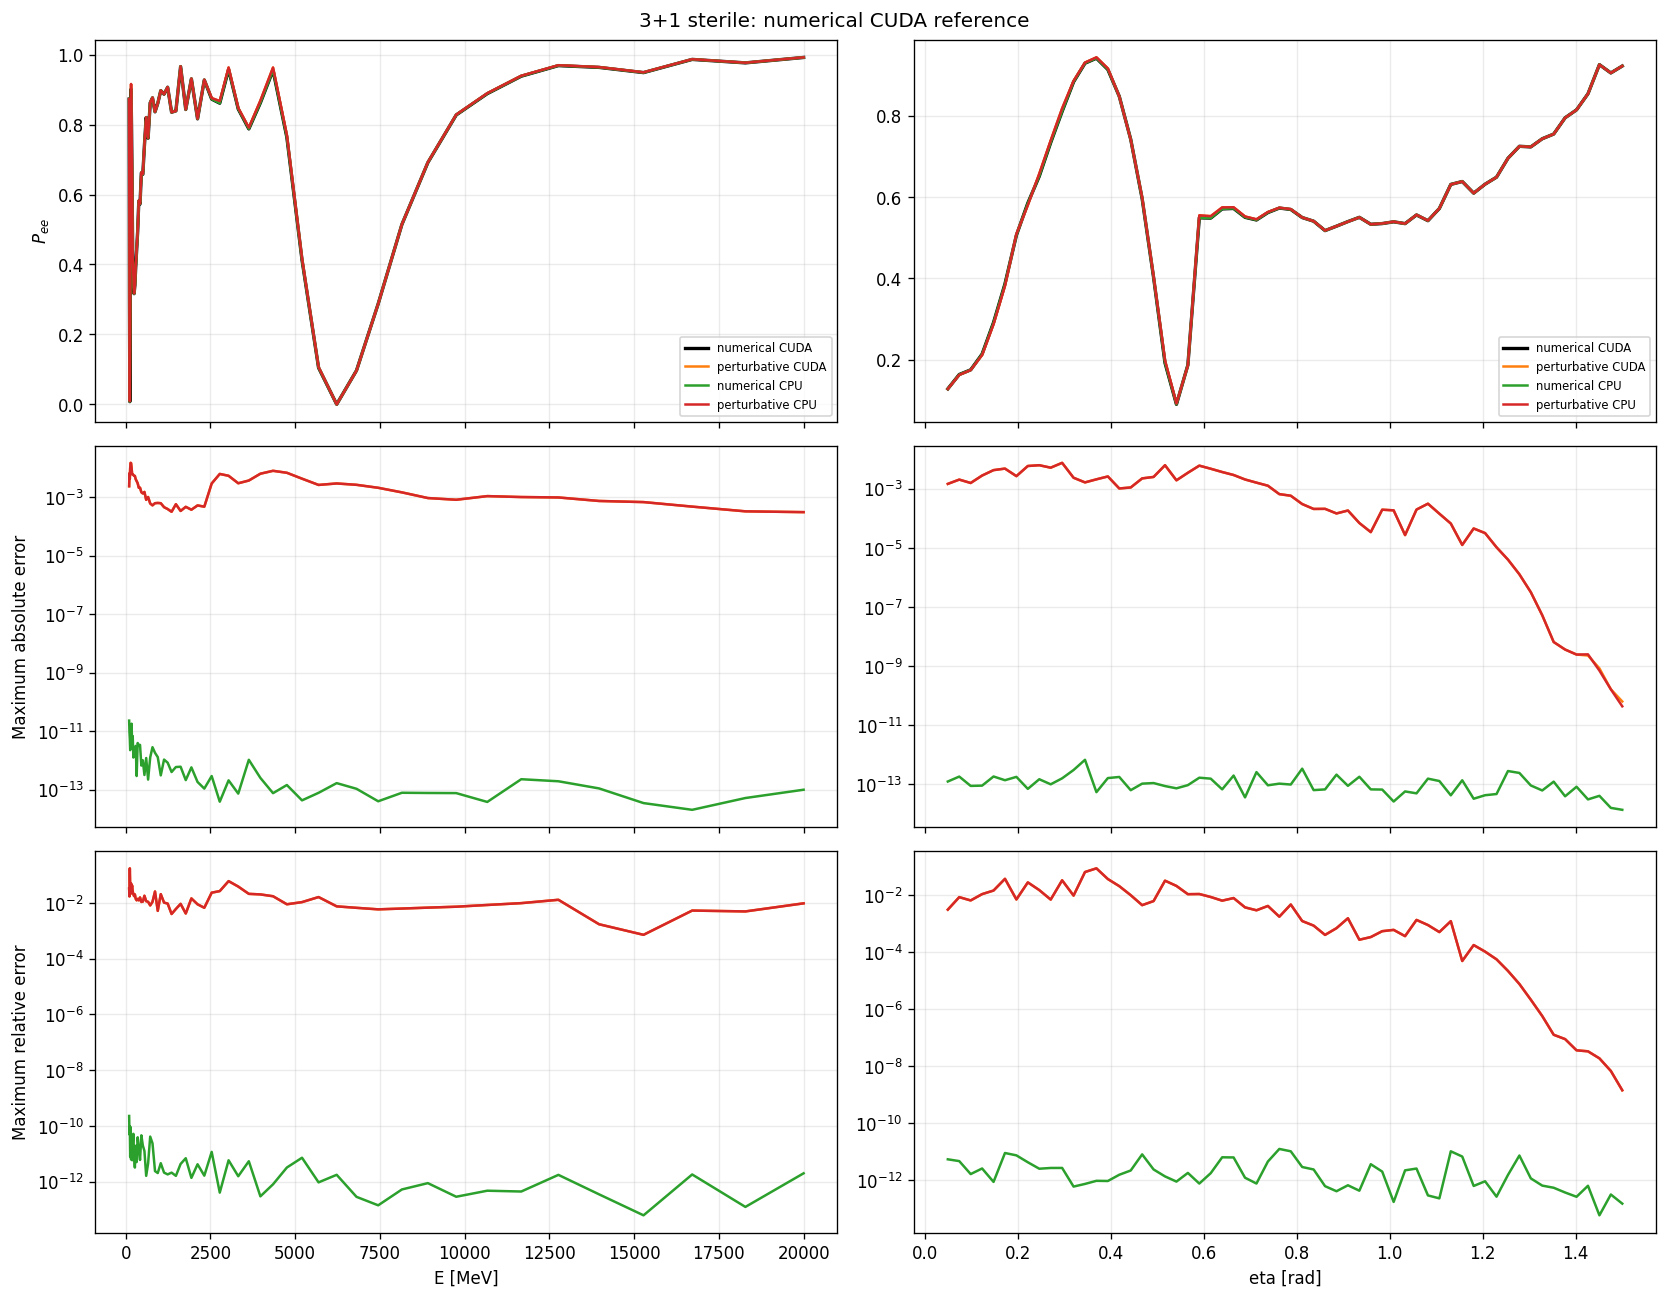

v:\output\validation\intrinsic\intrinsic6_sterile_fig52_device.png


In [7]:
precision_study('sterile','intrinsic6_sterile_fig51')
device_study('sterile','intrinsic6_sterile_fig52')


## 6. Summary
The final table combines all dtype and CPU/CUDA comparisons for the three physical models. Numerical `float64` is the reference for precision rows, while numerical CUDA is the reference for device rows.

The summary chart makes it possible to distinguish propagation-method discrepancies from dtype- or device-dependent effects. CPU/CUDA rows are available only when CUDA is present and Section 3-5 device studies complete successfully.

**Expected results:**<br>
- The summary observables are finite and reproduce the applicable analytical, numerical, or external-reference limit.
- Probability or flux normalization remains within the stated tolerance over the complete validation grid.
- Residuals exhibit the scaling and physical symmetries derived in the theoretical framework.


,max_abs,mean_abs,max_rel,mean_rel,normalization_numerical float64,normalization_perturbative float64,relative_points,absolute_threshold,normalization_numerical float32,normalization_perturbative float32,normalization_numerical CUDA,normalization_perturbative CUDA,normalization_numerical CPU,normalization_perturbative CPU
case,,,,,,,,,,,,,,
Standard Model: perturbative float64 vs numerical float64,1.600e-02,1.376e-03,1.558e-01,7.666e-03,8.571e-14,1.556e-02,3.540e+02,1.000e-03,nan,nan,nan,nan,nan,nan
Standard Model: numerical float32 vs numerical float64,1.036e-04,1.115e-05,1.747e-04,3.350e-05,8.571e-14,nan,3.540e+02,1.000e-03,1.089e-04,nan,nan,nan,nan,nan
Standard Model: perturbative float32 vs numerical float64,1.602e-02,1.377e-03,1.564e-01,7.669e-03,8.571e-14,nan,3.540e+02,1.000e-03,nan,1.557e-02,nan,nan,nan,nan
Standard Model: perturbative CUDA vs numerical CUDA,1.600e-02,1.376e-03,1.558e-01,7.666e-03,nan,nan,3.540e+02,1.000e-03,nan,nan,8.571e-14,1.556e-02,nan,nan
Standard Model: numerical CPU vs numerical CUDA,4.918e-14,2.381e-15,3.059e-13,1.020e-14,nan,nan,3.540e+02,1.000e-03,nan,nan,8.571e-14,nan,8.482e-14,nan
Standard Model: perturbative CPU vs numerical CUDA,1.600e-02,1.376e-03,1.558e-01,7.666e-03,nan,nan,3.540e+02,1.000e-03,nan,nan,8.571e-14,nan,nan,1.556e-02
NSI: perturbative float64 vs numerical float64,2.624e-02,1.538e-03,1.910e-01,1.242e-02,7.105e-14,2.365e-02,3.570e+02,1.000e-03,nan,nan,nan,nan,nan,nan
NSI: numerical float32 vs numerical float64,8.550e-05,1.070e-05,2.304e-04,3.364e-05,7.105e-14,nan,3.570e+02,1.000e-03,1.113e-04,nan,nan,nan,nan,nan
NSI: perturbative float32 vs numerical float64,2.624e-02,1.539e-03,1.903e-01,1.242e-02,7.105e-14,nan,3.570e+02,1.000e-03,nan,2.367e-02,nan,nan,nan,nan


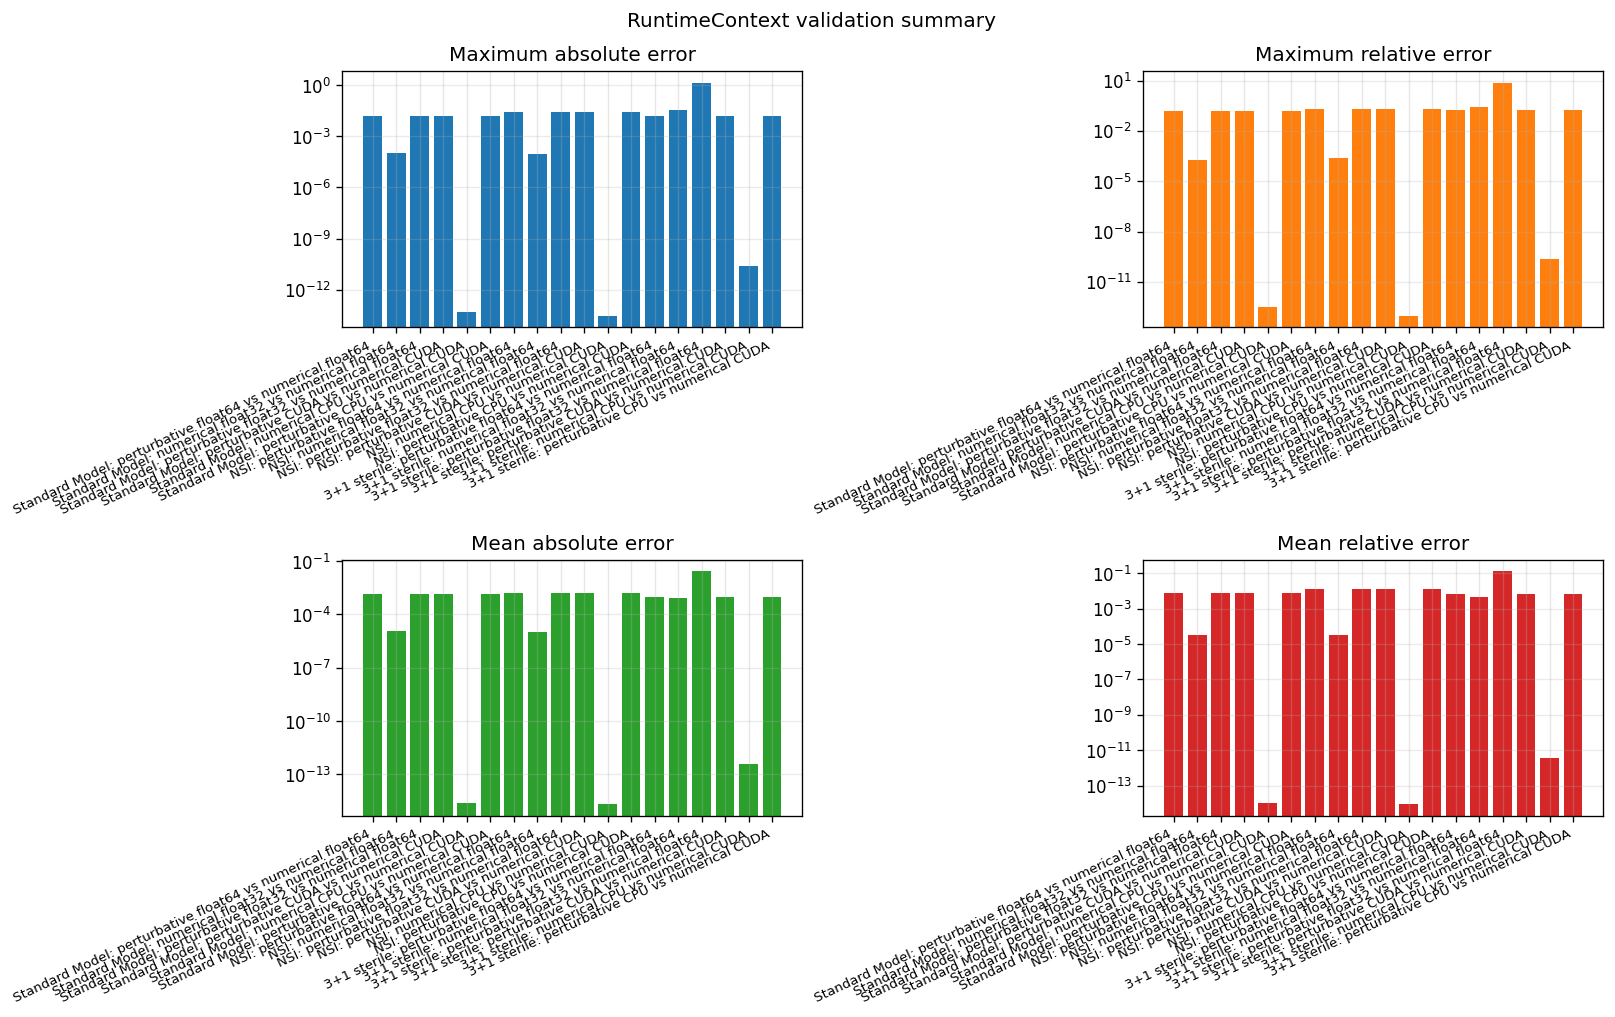

v:\output\validation\intrinsic\intrinsic6_fig6_summary.png


In [8]:
runtime_summary = pd.DataFrame(RUNTIME_SUMMARIES).set_index('case')
display(runtime_summary.style.format({column: '{:.3e}' for column in runtime_summary.select_dtypes(include='number').columns}))
validation_summary_plot(RUNTIME_SUMMARIES, title='RuntimeContext validation summary', filename='intrinsic6_fig6_summary.png', output_dir=OUTPUT_DIR, show_plots=config.show_plots)
assert np.isfinite(runtime_summary[['max_abs','mean_abs','max_rel','mean_rel']].to_numpy()).all()
